In [1]:
import pandas as pd
from braindecode.preprocessing import create_fixed_length_windows

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)

In [1]:
from TUEP import TUHEpilepsy

EPILEPSY_PATH='/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy'

print(flush=True)

tuep=TUHEpilepsy(path=EPILEPSY_PATH,set_montage=False,rename_channels=True,target_name='epilepsy', n_jobs=4)

/users/gzanardini/eeg_thesis/TUEP.py:146: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:146: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:146: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:146: RuntimeWarning: The unit for channel(s) 28, 29, 30, EKG, PG1, PG2, PHOTIC PH, SP1, SP2, T1, T2 has changed from V to NA.
  raw.set_channel_types(mapping_non_eeg_types)
/users/gzanardini/eeg_thesis/TUEP.py:146: RuntimeWarning: The unit for channel(s) 30, EKG, LUC, PG1, PG2, PHOTIC PH, RLC, SP1, SP2, T1, T2 has changed from V 

In [2]:
print(tuep.description['epilepsy'].value_counts())
print(len(tuep.datasets))


Y    1785
N     513
Name: epilepsy, dtype: int64
2298


In [4]:
def filter_datasets_and_description(tuep, lenght_s=60):
    indices_to_pop = []
    for i, dataset in enumerate(tuep.datasets):
        if dataset.raw.times[-1] <= lenght_s:
            indices_to_pop.append(i)
                
    print(f"Filtering datasets from {len(tuep.datasets)} to {len(tuep.datasets) - len(indices_to_pop)}")

    # Filter datasets
    tuep.datasets = [dataset for i, dataset in enumerate(tuep.datasets) if i not in indices_to_pop]    
    print('Sanity Check:' , len(tuep.datasets))

    # Filter description DataFrame
    desc = tuep.description.drop(indices_to_pop, axis=0)
    tuep.set_description(desc, overwrite=True)
    return tuep

# Call the function to filter the datasets and description
tuep_clean=filter_datasets_and_description(tuep)

print(tuep_clean.description['epilepsy'].value_counts())

Filtering datasets from 2049 to 2049
Sanity Check: 2049
Y    1659
N     390
Name: epilepsy, dtype: int64


In [16]:
from braindecode.preprocessing import preprocess, Preprocessor, create_fixed_length_windows

savedir='/space/gzanardini/tuh_eeg/tuh_eeg_epilepsy/preprocessed'

#preprocs=[Preprocessor('crop', tmin=10)]
#preprocess(tuep, preprocs, save_dir=savedir, overwrite=True, n_jobs=8)

windows_tuep=create_fixed_length_windows(tuep, window_size_samples=200, window_stride_samples=200, drop_last_window=True)

In [ ]:
def resample_data(ds, target_freq=250):
    for i in range(len(ds)):
        if ds[i].raw.info['sfreq'] != target_freq:
            print(f"Resampling recording {i} from {ds[i].raw.info['sfreq']} Hz to {target_freq} Hz")
            ds[i].raw.resample(target_freq,n_jobs=4)
        elif ds[i].raw.info['sfreq'] == target_freq:
            print(f"Recording {i} already at {target_freq} Hz")
    return ds

tuep.datasets[:200]=resample_data(tuep.datasets[:200], target_freq=250)

Recording 0 contains PHOTIC PH


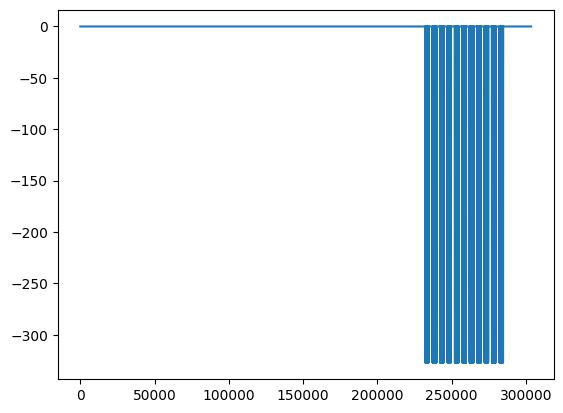

Recording 1 contains PHOTIC PH


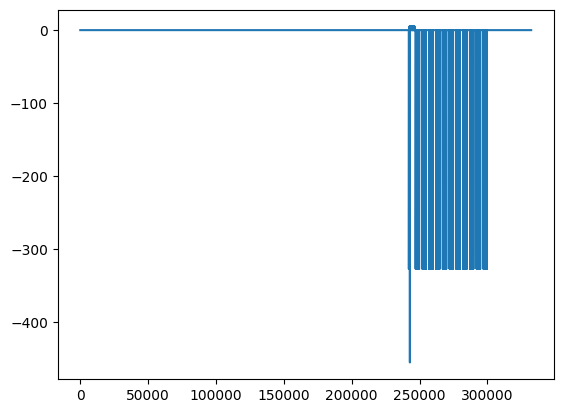

Recording 2 contains PHOTIC PH


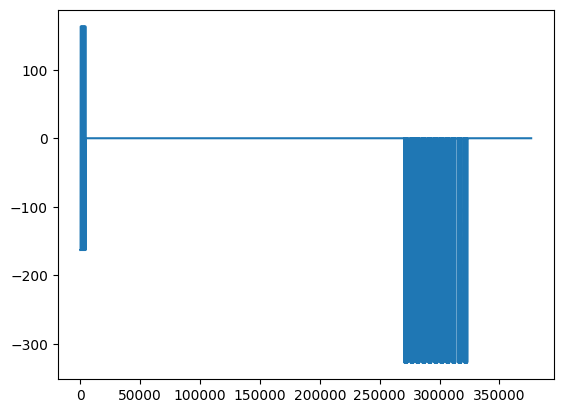

Recording 3 contains PHOTIC PH


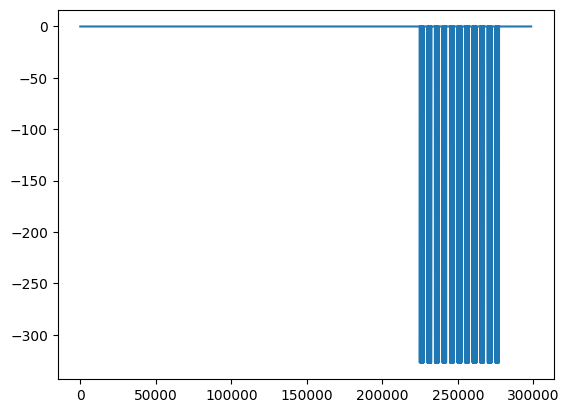

Recording 4 contains PHOTIC PH


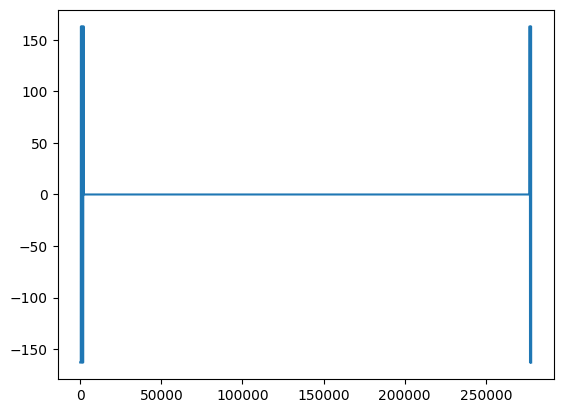

Recording 5 contains PHOTIC PH


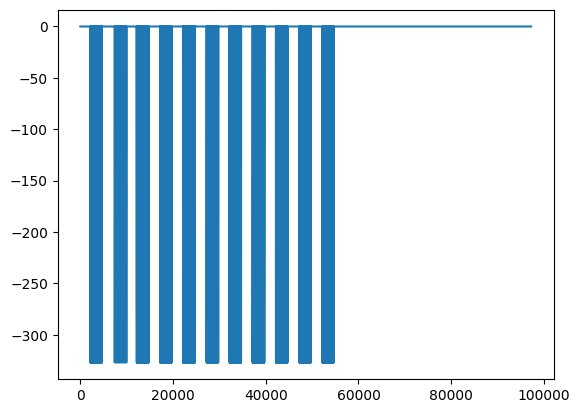

Recording 6 contains PHOTIC PH


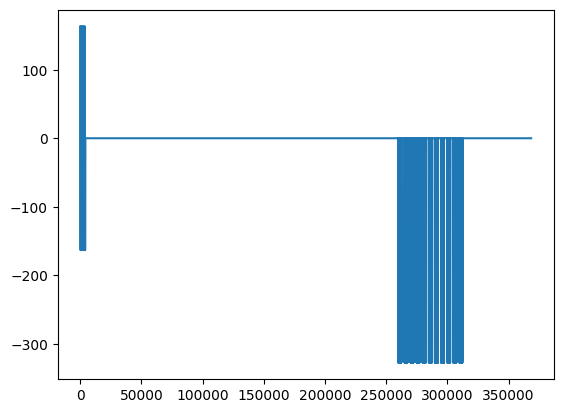

Recording 7 contains PHOTIC PH


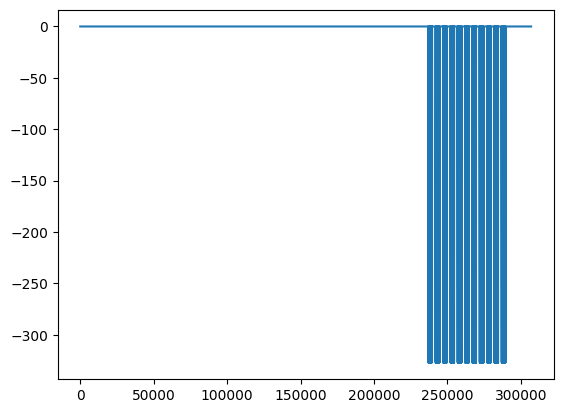

Recording 8 contains PHOTIC PH


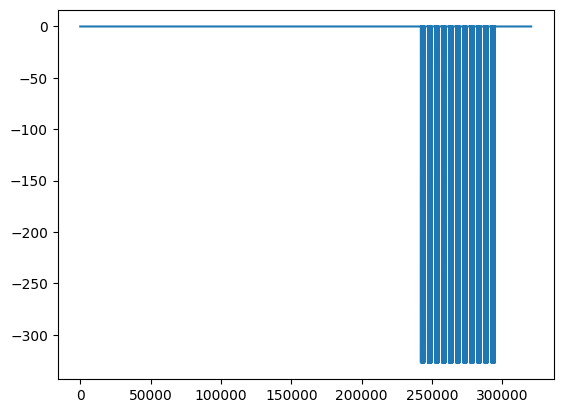

Recording 9 contains PHOTIC PH


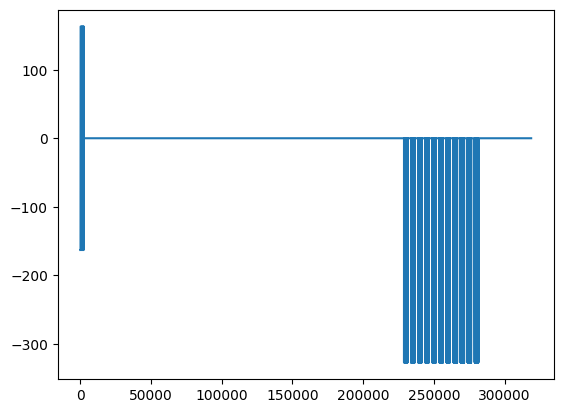

Recording 10 contains PHOTIC PH


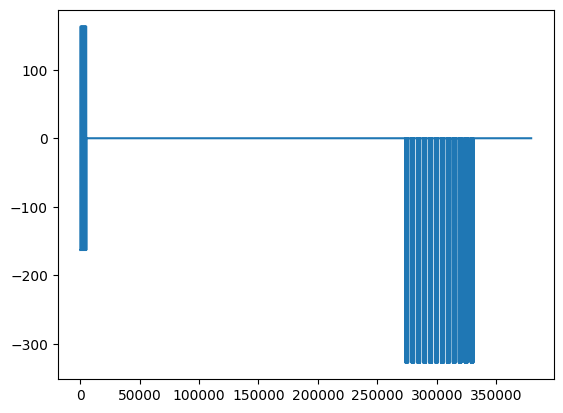

Recording 11 contains PHOTIC PH


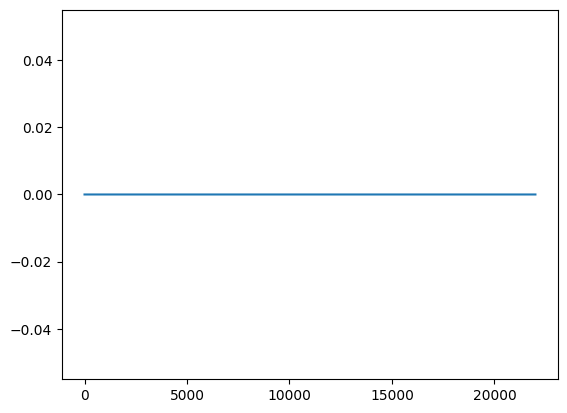

Recording 12 contains PHOTIC PH


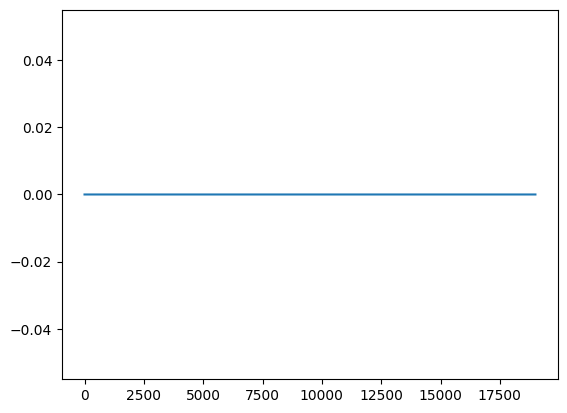

Recording 13 contains PHOTIC PH


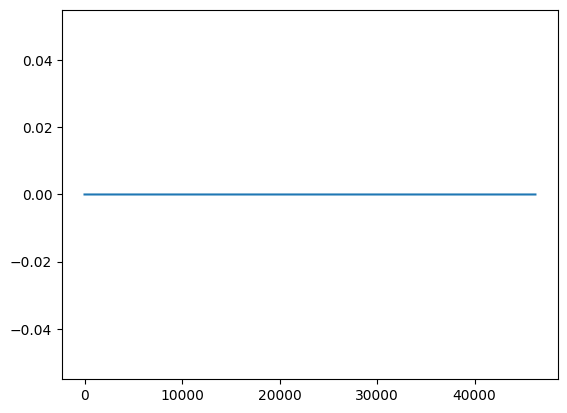

Recording 14 contains PHOTIC PH


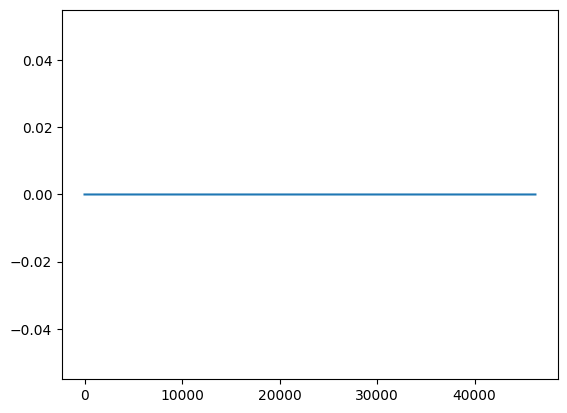

Recording 15 contains PHOTIC PH


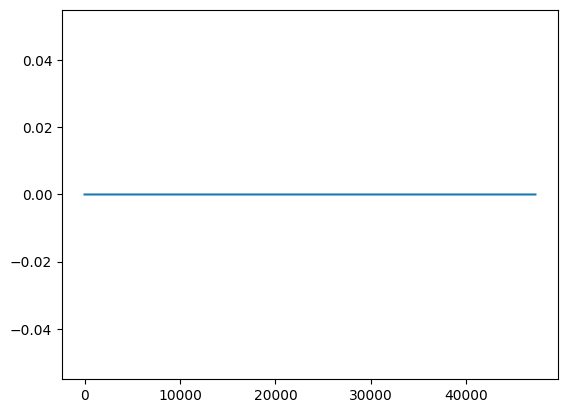

Recording 16 contains PHOTIC PH


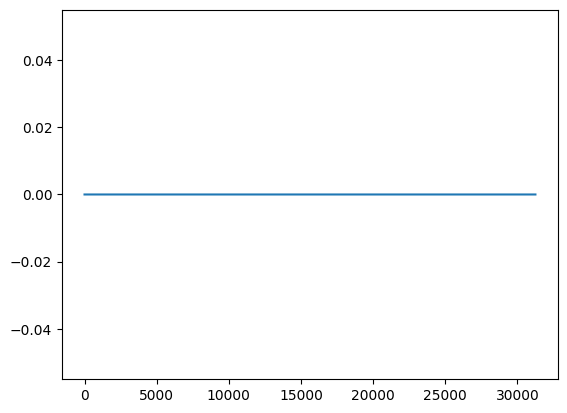

Recording 17 contains PHOTIC PH


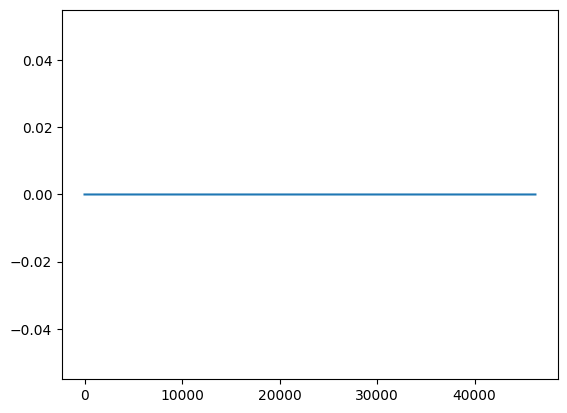

Recording 18 contains PHOTIC PH


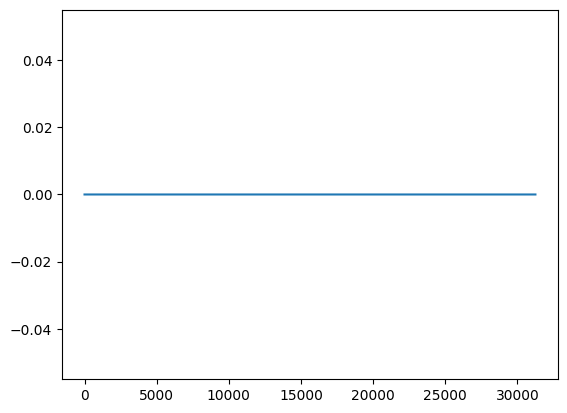

Recording 19 contains PHOTIC PH


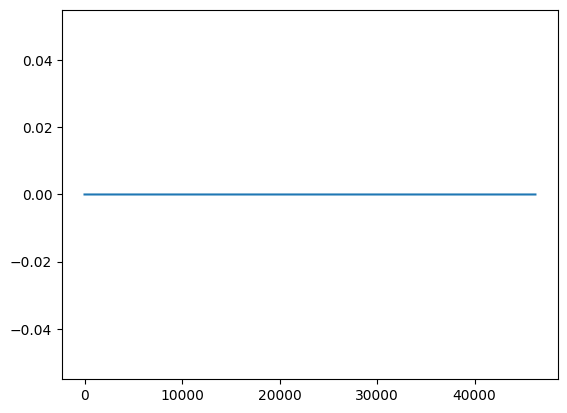

Recording 20 contains PHOTIC PH


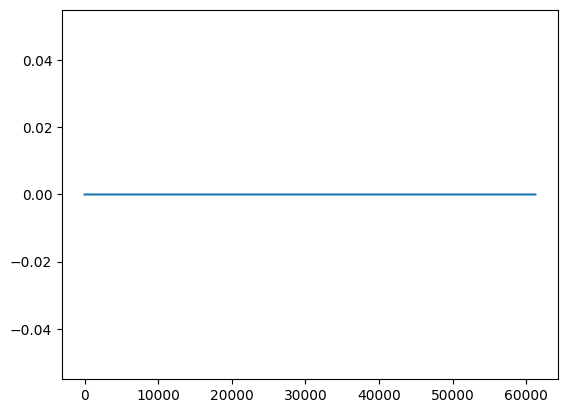

Recording 21 contains PHOTIC PH


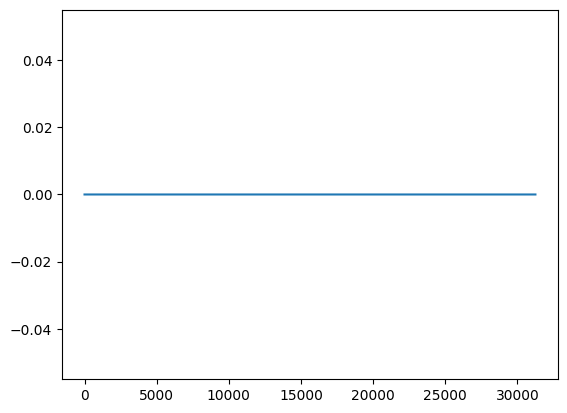

Recording 22 contains PHOTIC PH


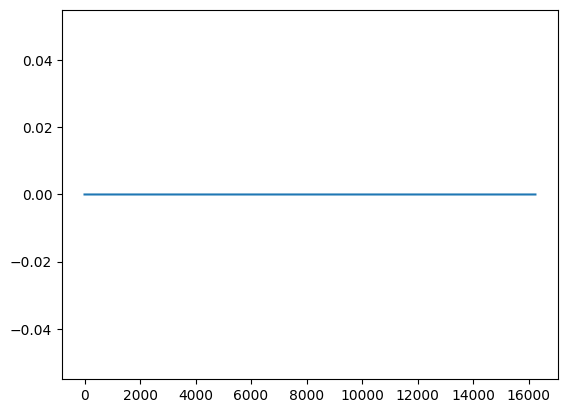

Recording 23 contains PHOTIC PH


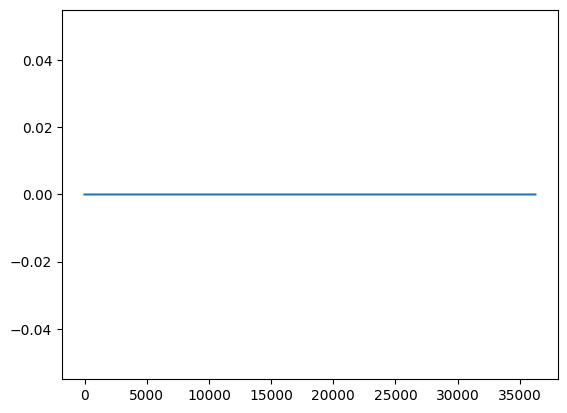

Recording 24 contains PHOTIC PH


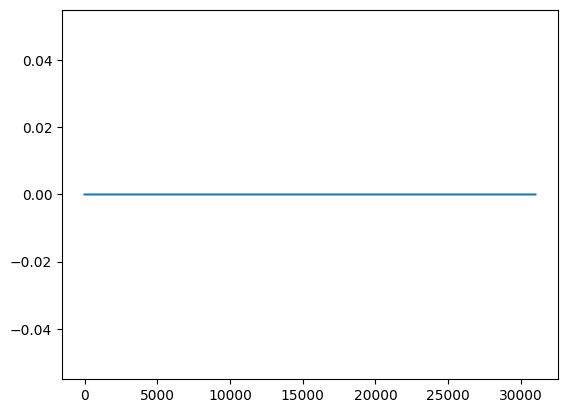

Recording 25 contains PHOTIC PH


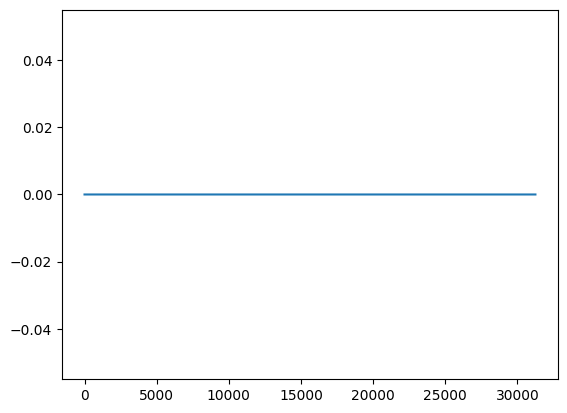

Recording 26 contains PHOTIC PH


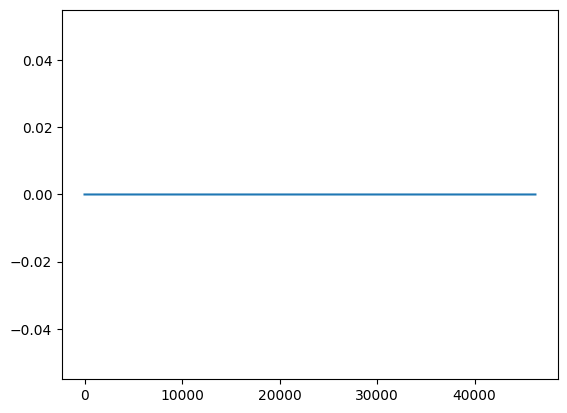

Recording 27 contains PHOTIC PH


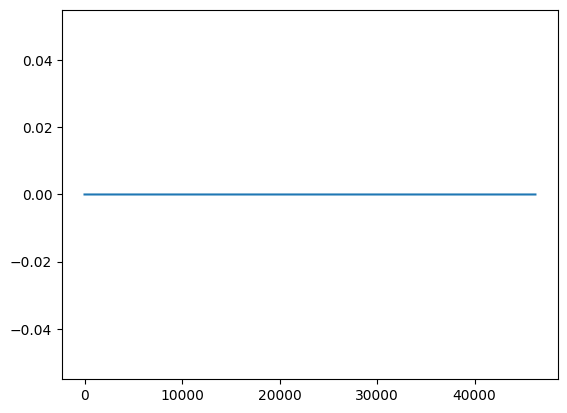

Recording 28 contains PHOTIC PH


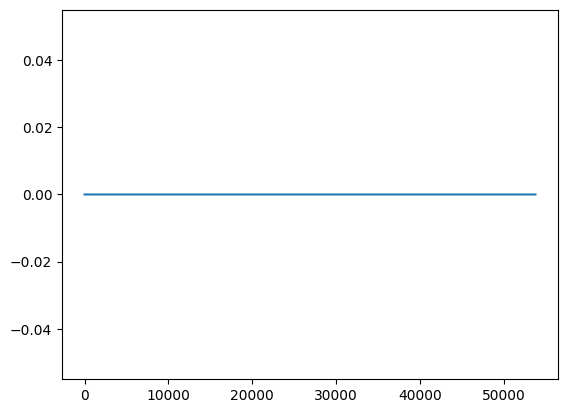

Recording 29 contains PHOTIC PH


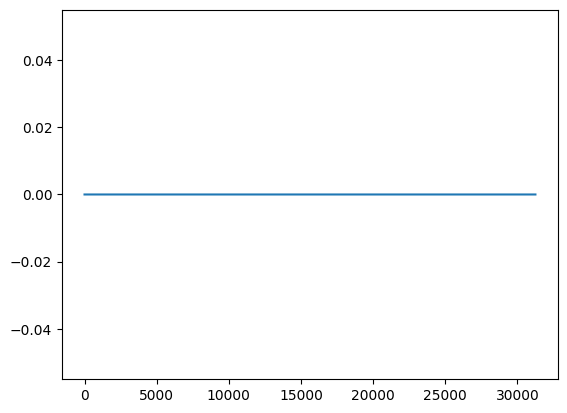

Recording 30 contains PHOTIC PH


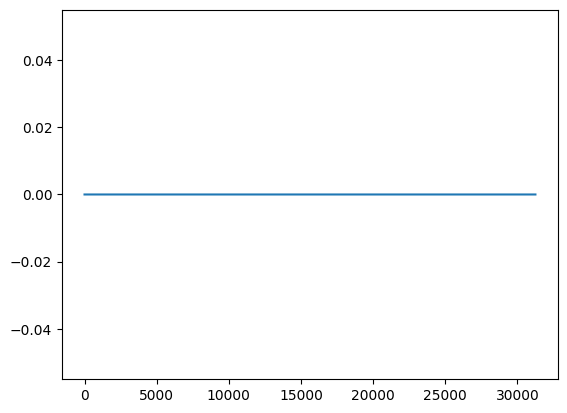

Recording 31 contains PHOTIC PH


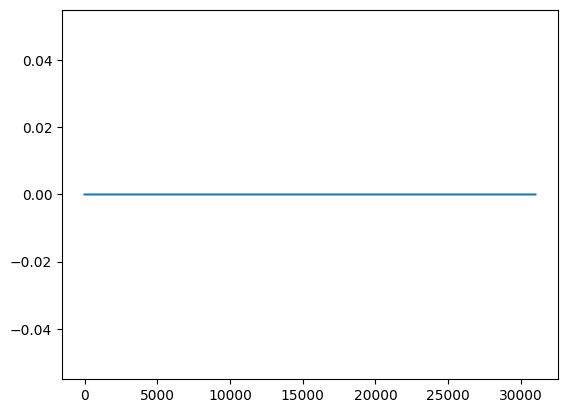

Recording 32 contains PHOTIC PH


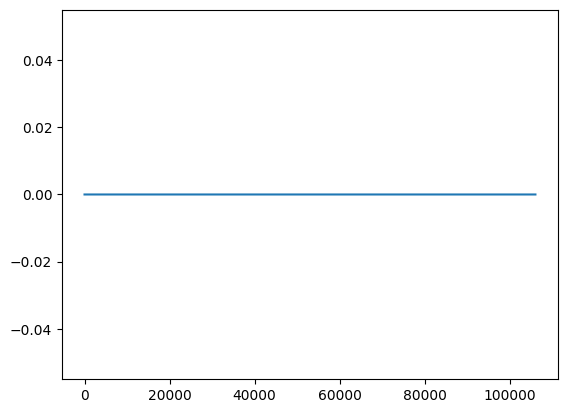

Recording 33 contains PHOTIC PH


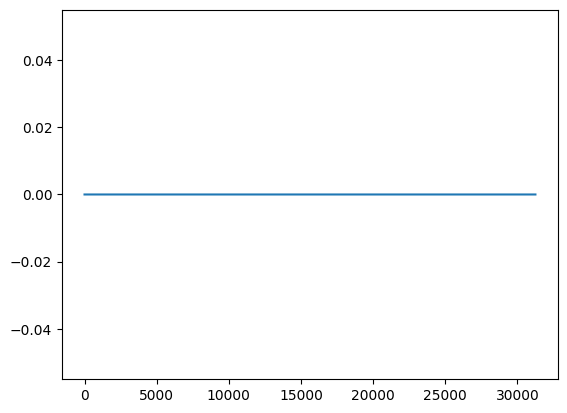

Recording 34 contains PHOTIC PH


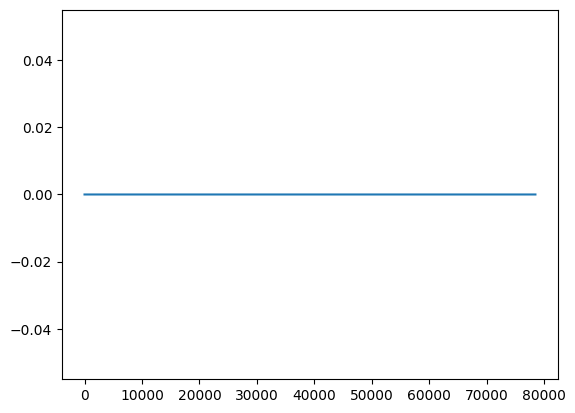

Recording 35 contains PHOTIC PH


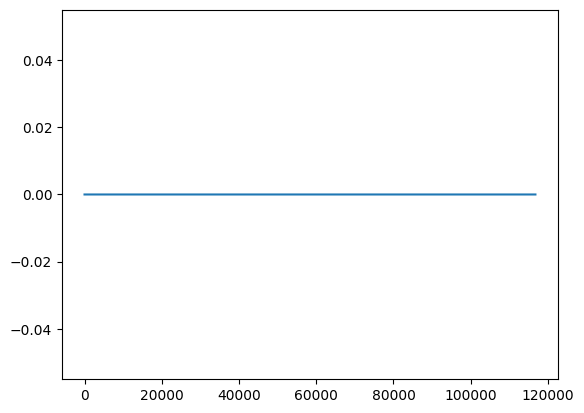

Recording 36 contains PHOTIC PH


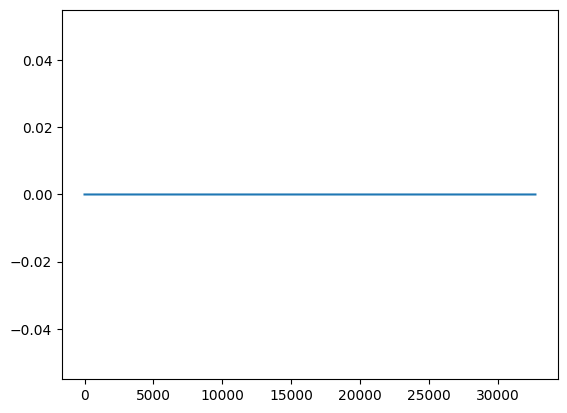

Recording 37 contains PHOTIC PH


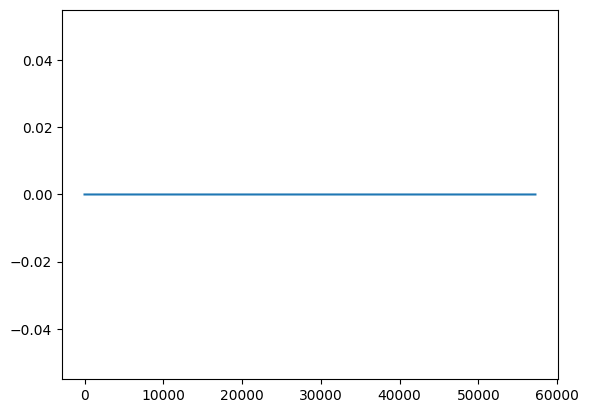

Recording 38 contains PHOTIC PH


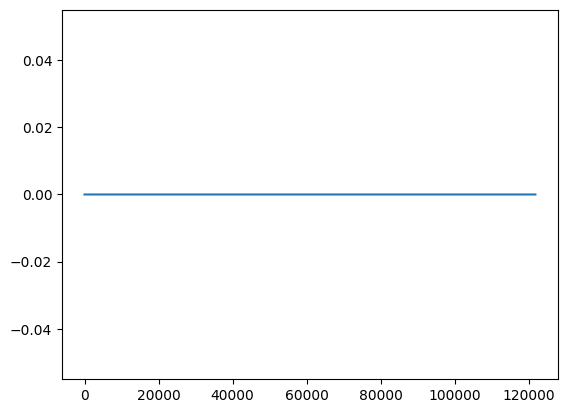

Recording 39 contains PHOTIC PH


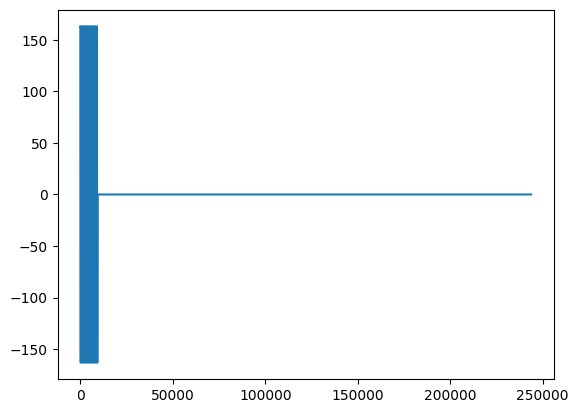

Recording 40 contains PHOTIC PH


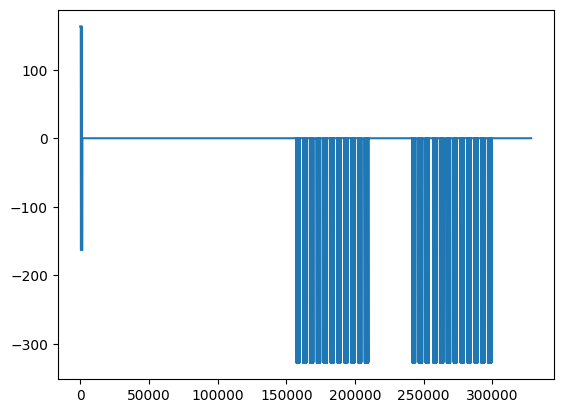

Recording 41 contains PHOTIC PH


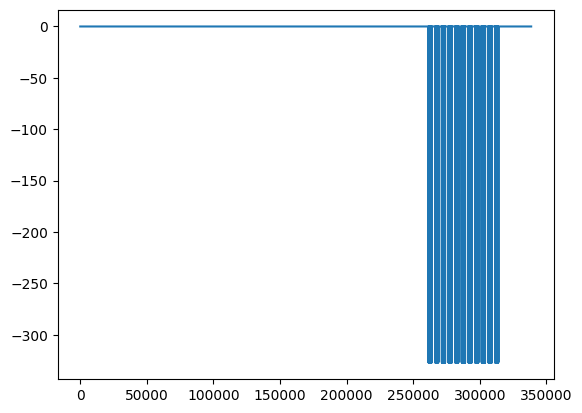

Recording 42 contains PHOTIC PH


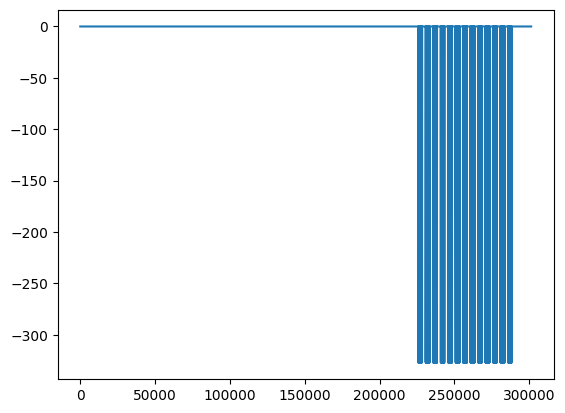

Recording 43 contains PHOTIC PH


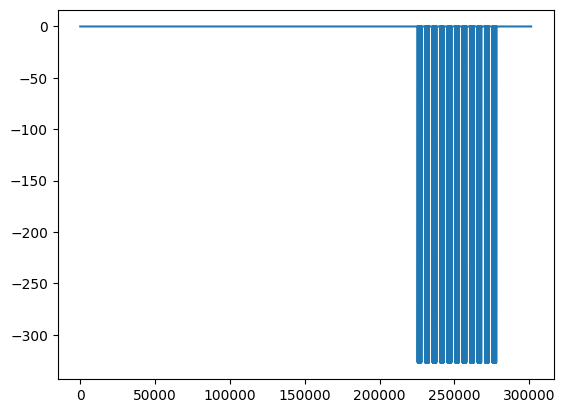

Recording 44 contains PHOTIC PH


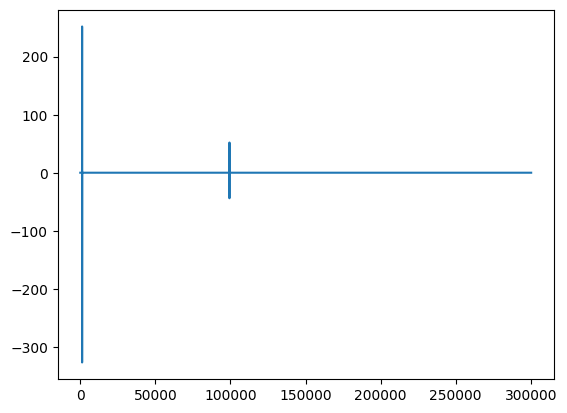

Recording 45 contains PHOTIC PH


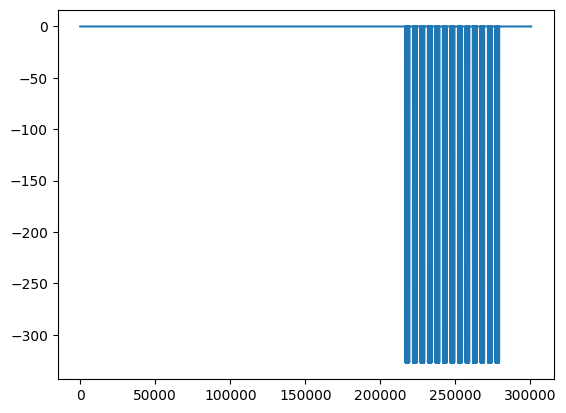

Recording 46 contains PHOTIC PH


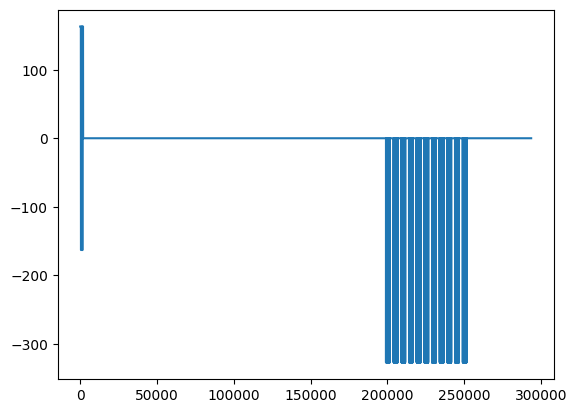

Recording 47 contains PHOTIC PH


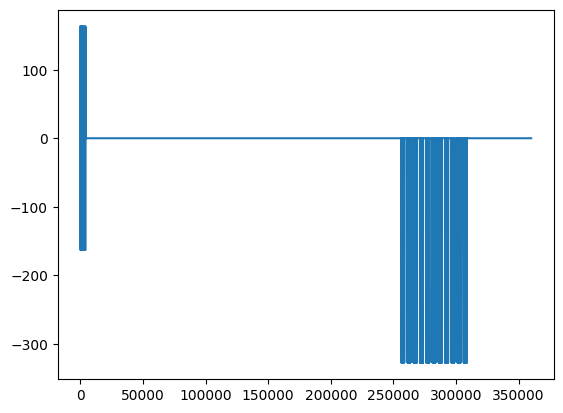

Recording 48 contains PHOTIC PH


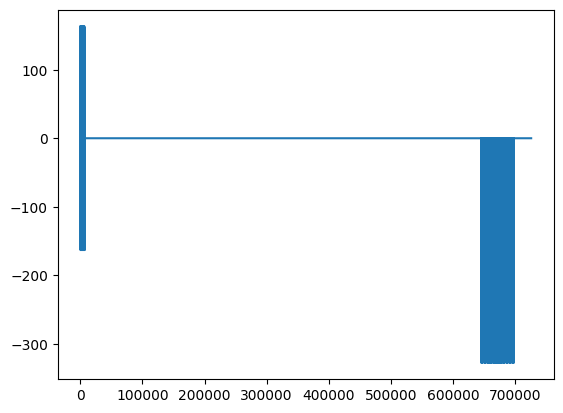

Recording 49 contains PHOTIC PH


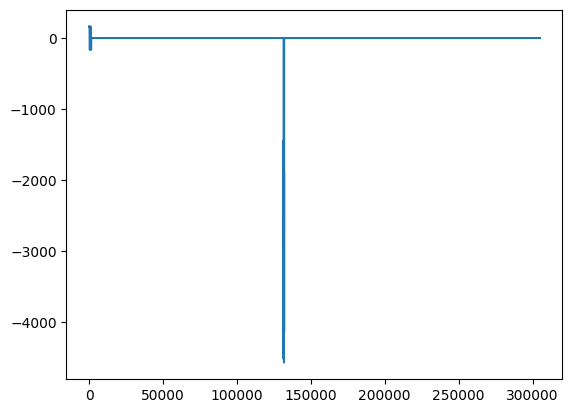

Recording 50 contains PHOTIC PH


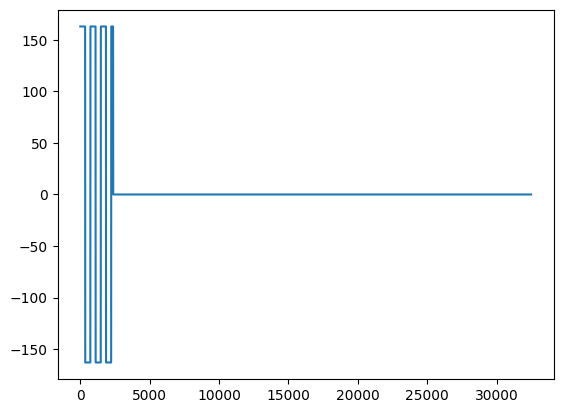

Recording 51 contains PHOTIC PH


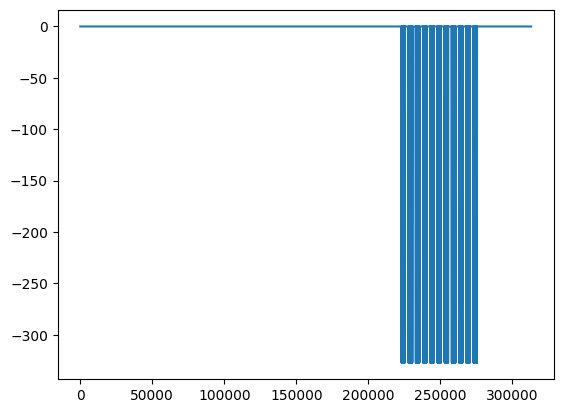

Recording 52 contains PHOTIC PH


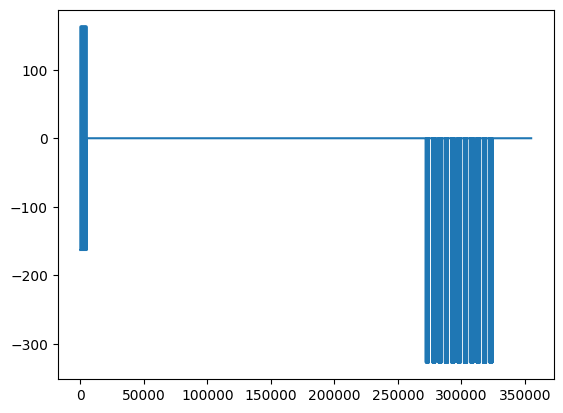

Recording 62 contains PHOTIC PH


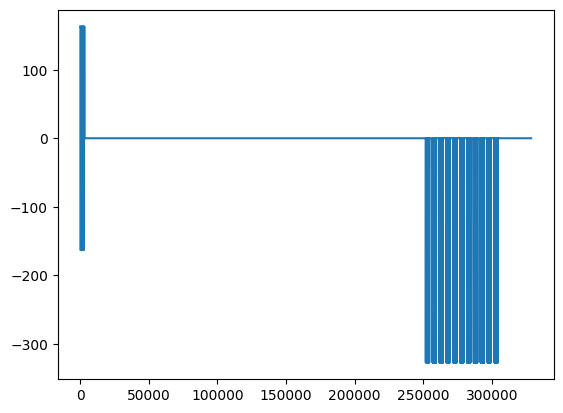

Recording 63 contains PHOTIC PH


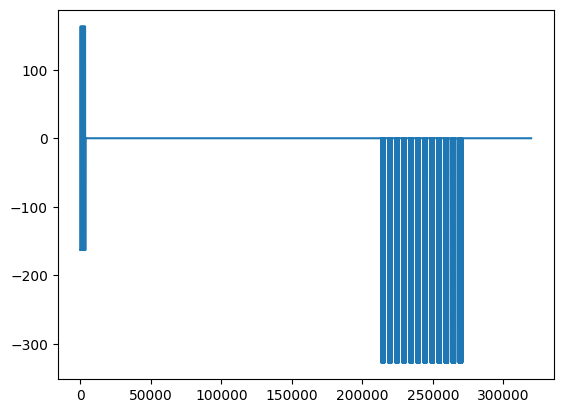

Recording 69 contains PHOTIC PH


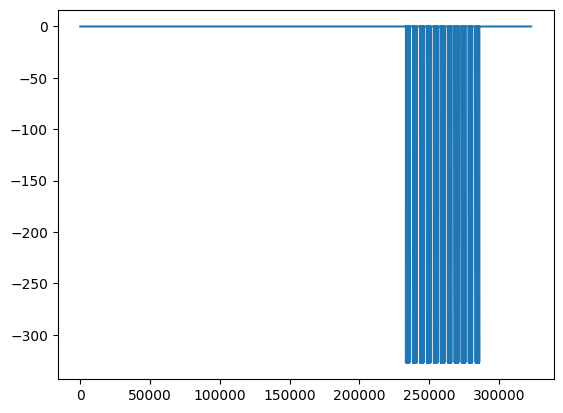

Recording 70 contains PHOTIC PH


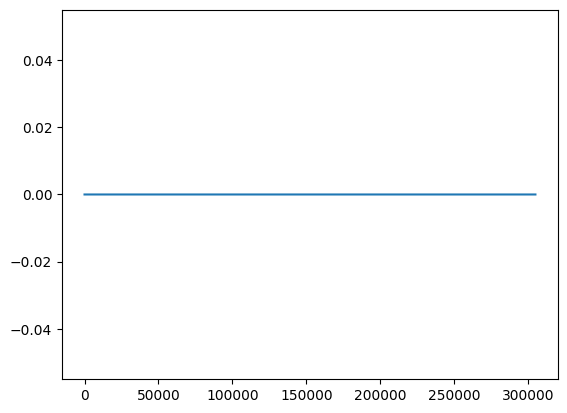

Recording 71 contains PHOTIC PH


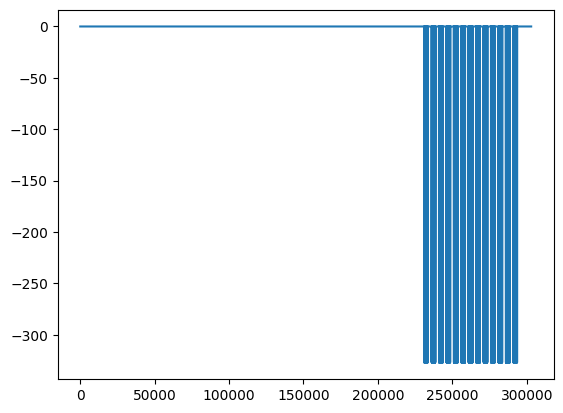

Recording 76 contains PHOTIC PH


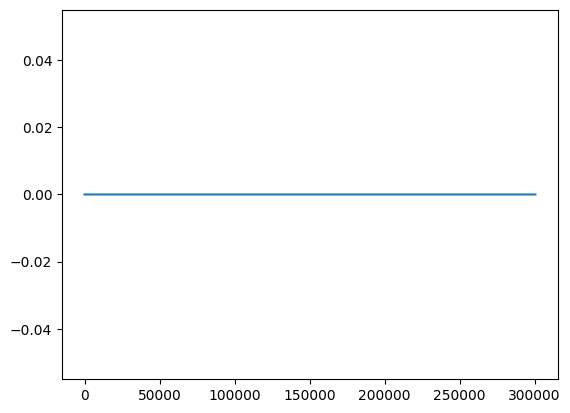

Recording 77 contains PHOTIC PH


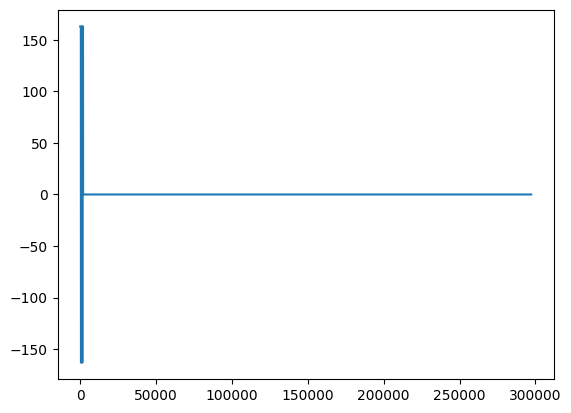

Recording 79 contains PHOTIC PH


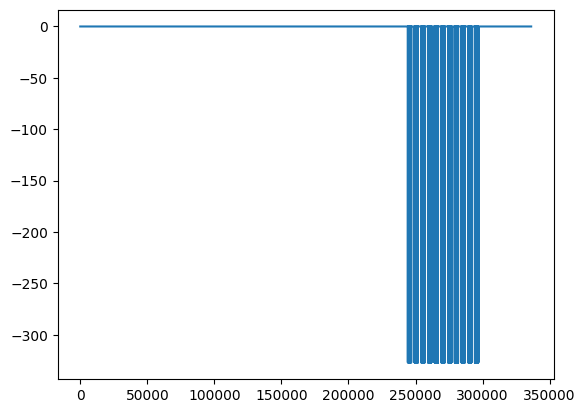

Recording 81 contains PHOTIC PH


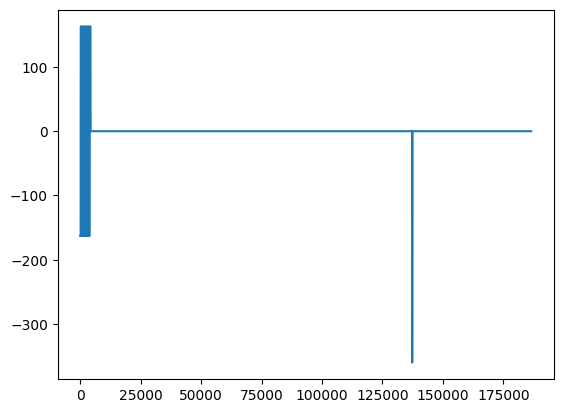

Recording 82 contains PHOTIC PH


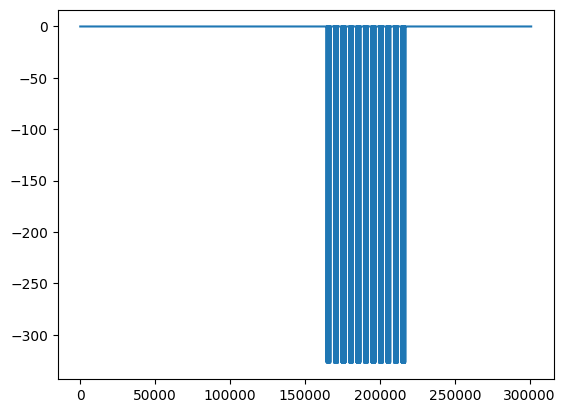

Recording 129 contains PHOTIC PH


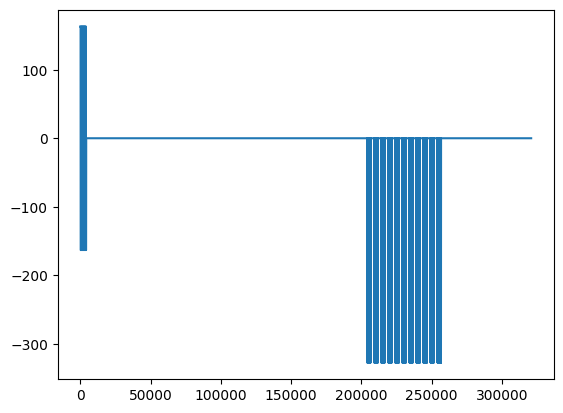

Recording 131 contains PHOTIC PH


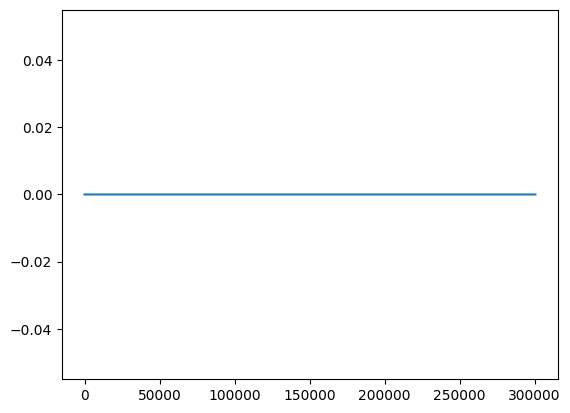

Recording 136 contains PHOTIC PH


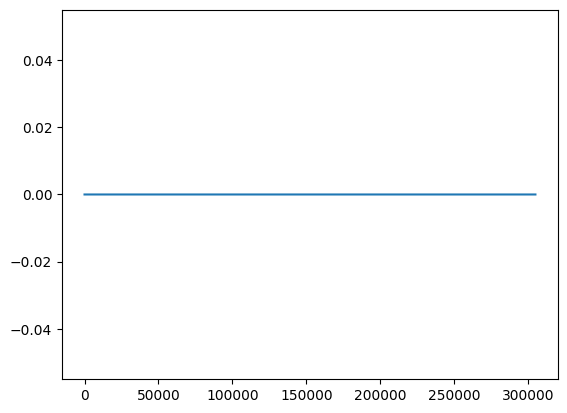

Recording 138 contains PHOTIC PH


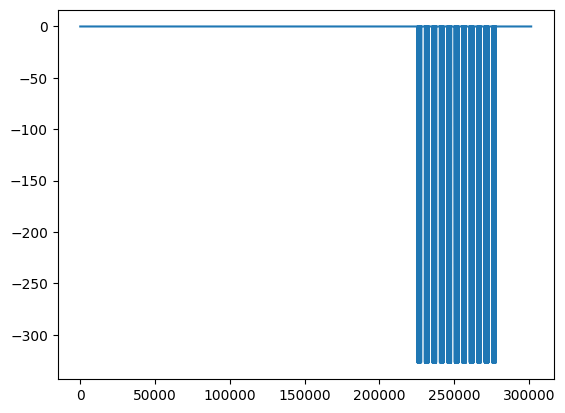

Recording 140 contains PHOTIC PH


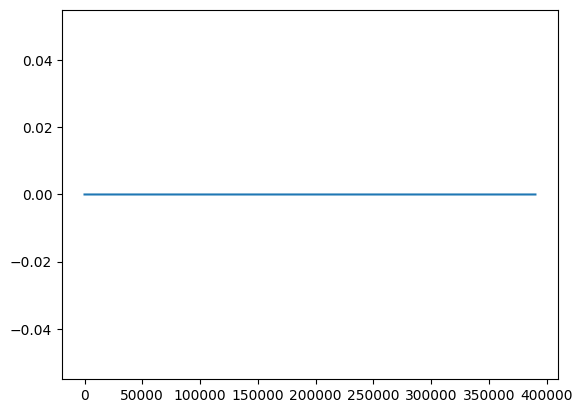

Recording 141 contains PHOTIC PH


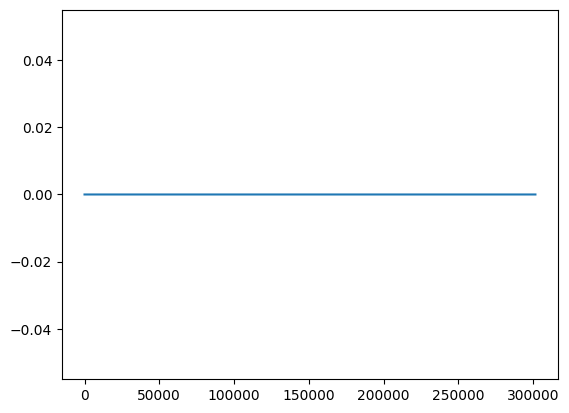

Recording 148 contains PHOTIC PH


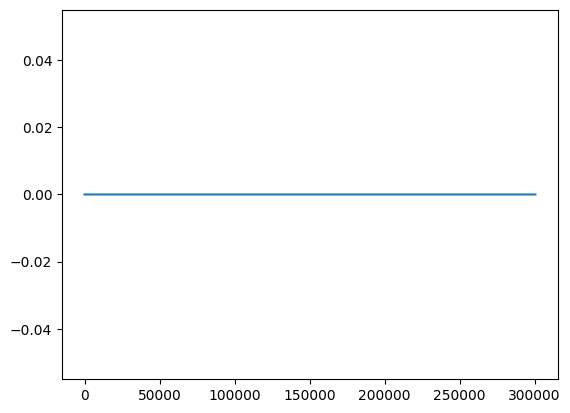

Recording 158 contains PHOTIC PH


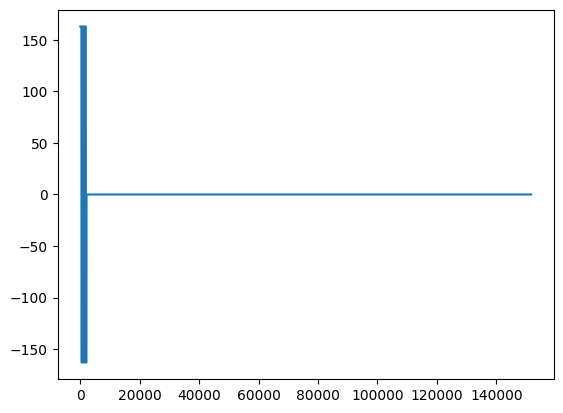

Recording 159 contains PHOTIC PH


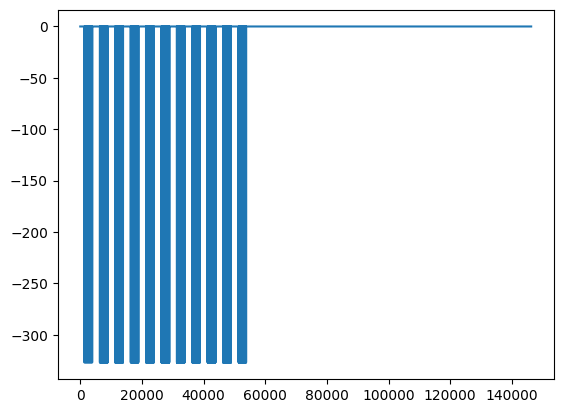

Recording 161 contains PHOTIC PH


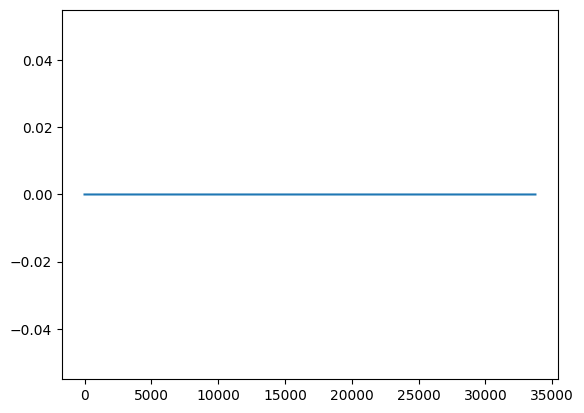

Recording 162 contains PHOTIC PH


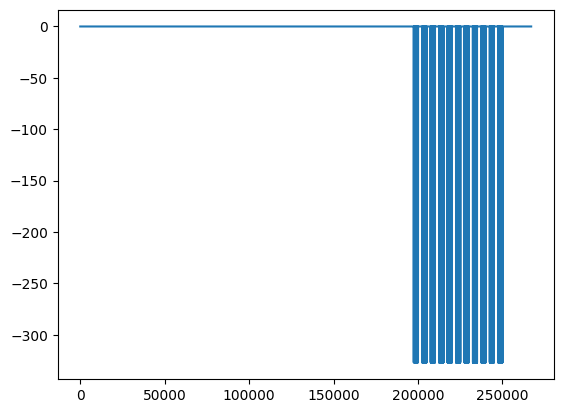

Recording 175 contains PHOTIC PH


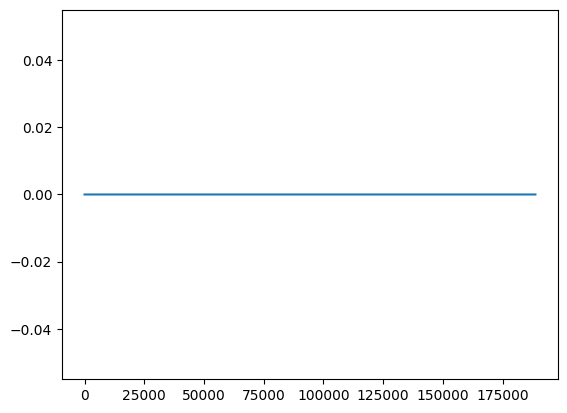

Recording 176 contains PHOTIC PH


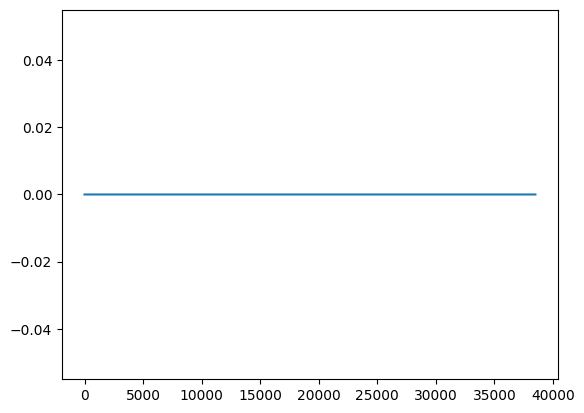

Recording 177 contains PHOTIC PH


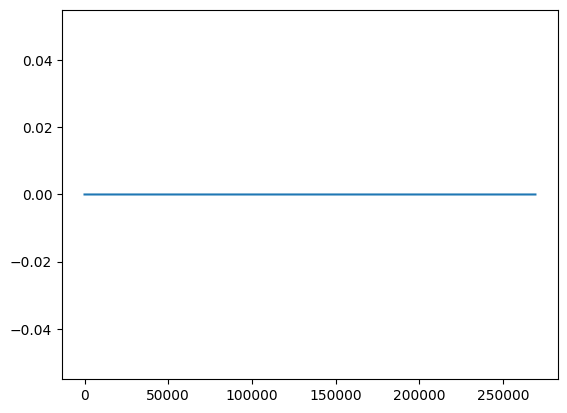

In [5]:
import matplotlib.pyplot as plt 

for i, set in enumerate(tuep.datasets[:200]):
    if 'PHOTIC PH' in set.raw.ch_names:
        print(f"Recording {i} contains PHOTIC PH")
        plt.figure()
        plt.plot(set.raw.get_data(picks='PHOTIC PH')[0])
        plt.show()        

In [ ]:
'''tuep.datasets[0].raw['PHOTIC PH'][0]
tuep.datasets[0].raw['PHOTIC PH'][1]'''

#set.raw['PHOTIC PH'][0]

plt.figure()
plt.plot(tuep.datasets[0].raw['PHOTIC PH'][0])
#plt.plot(set.raw.get_data(picks='PHOTIC PH')[1])
plt.show()